In [1]:
import numpy as np
import pandas as pd
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/home/onyxia/work/Projet-de-Statapp---WFP-/NIGERIA_WFP_ENGINEERED.csv")

In [3]:
df

,NAME_1,time,inadequate,bnds,Y,X,Evap_tavg,LWdown_f_tavg,Lwnet_tavg,Psurf_f_tavg,...,FPAR_Lag_2,FPAR_Lag_3,FPAR_Lag_4,FPAR_Lag_5,FPAR_Lag_6,acled_events,acled_fatalities,acled_events_cum3,acled_fatalities_cum3,acled_events_lag1
0,Abia,2023-01-01,0.296774,0.5,5.395000,7.471889,0.000016,385.566324,-71.064699,99941.271400,...,NaN,NaN,NaN,NaN,NaN,2.0,4.0,8.0,7.0,2.0
1,Abia,2023-02-01,0.401515,0.5,5.395000,7.471889,0.000014,392.934595,-69.757725,99864.297600,...,NaN,NaN,NaN,NaN,NaN,6.0,5.0,10.0,9.0,2.0
2,Abia,2023-03-01,0.281046,0.5,5.395000,7.471889,0.000026,408.719824,-44.999965,99913.329933,...,-0.551000,NaN,NaN,NaN,NaN,1.0,1.0,9.0,10.0,6.0
3,Abia,2023-04-01,0.300613,0.5,5.395000,7.471889,0.000030,416.609924,-39.776577,99798.052400,...,NaN,-0.551000,NaN,NaN,NaN,2.0,4.0,9.0,10.0,1.0
4,Abia,2023-05-01,0.226667,0.5,5.395000,7.471889,0.000039,419.145751,-35.249339,99990.250067,...,0.264333,NaN,-0.551000,NaN,NaN,3.0,3.0,6.0,8.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,Zamfara,2025-08-01,0.500000,0.5,12.281723,6.331793,0.000056,399.689712,-45.163207,96580.019643,...,-0.026667,-0.421000,0.257333,0.486000,0.307000,81.0,244.0,184.0,585.0,51.0
1076,Zamfara,2025-09-01,0.453333,0.5,12.281723,6.331793,0.000062,401.024427,-45.901838,96565.790857,...,0.138667,-0.026667,-0.421000,0.257333,0.486000,67.0,148.0,199.0,567.0,81.0
1077,Zamfara,2025-10-01,0.427673,0.5,12.281723,6.331793,0.000055,370.418978,-81.860593,96497.265000,...,0.234000,0.138667,-0.026667,-0.421000,0.257333,59.0,99.0,207.0,491.0,67.0
1078,Zamfara,2025-11-01,0.415301,0.5,12.281723,6.331793,0.000021,334.451814,-120.701201,96528.654000,...,0.441333,0.234000,0.138667,-0.026667,-0.421000,56.0,79.0,182.0,326.0,59.0


In [3]:
df = df.sort_values(['NAME_1', 'time'])
for l in [1, 2, 3]:
    df[f'inadequate_lag{l}'] = df.groupby('NAME_1')['inadequate'].shift(l)
df['delta_inadequate'] = df.groupby('NAME_1')['inadequate'].diff()

In [4]:
def analyze_optimal_lag(df, state_name, target_var='inadequate',
                        climate_var='WSI', max_lag=6, plot=False):
    col_state = 'NAME_1'
    df_state = df[df[col_state] == state_name].sort_values('time')

    lags = range(max_lag + 1)
    corrs = []

    for lag in lags:
        col = climate_var if lag == 0 else f'{climate_var}_Lag_{lag}'
        if col in df_state.columns:
            valid = df_state[[target_var, col]].dropna()
            corrs.append(valid[target_var].corr(valid[col]) if len(valid) > 2 else 0)
        else:
            corrs.append(0)

    best_lag = lags[np.argmax(np.abs(corrs))]
    best_corr = corrs[np.argmax(np.abs(corrs))]

    return {'state': state_name, 'best_lag': best_lag, 'correlation': best_corr}

climate_features = [
    'Evap_tavg','Rainf_f_tavg','Tair_f_tavg','Qair_f_tavg',
    'Wind_f_tavg','SoilMoi40_100cm_tavg','WSI',
    'soil_anomaly','rain_anomaly','ndvi_anomaly'
]

lag_results = []

for var in climate_features:
    for state in df['NAME_1'].unique():
        res = analyze_optimal_lag(df, state, climate_var=var)
        if res:
            res['variable'] = var
            lag_results.append(res)

df_all_lags = pd.DataFrame(lag_results)

all_climate_vars = [
    'Evap_tavg','Rainf_f_tavg','Tair_f_tavg','Qair_f_tavg',
    'Wind_f_tavg','SoilMoi40_100cm_tavg','WSI',
    'SPI_Cum1','SPI_Cum3','SPI_Cum6'
]

for var in all_climate_vars:
    if var not in df.columns:
        continue

    if var in df_all_lags['variable'].unique():

        best_map = df_all_lags[df_all_lags['variable'] == var] \
            .set_index('state')['best_lag']

        def build_opt(row, var=var, bm=best_map):
            lag = int(bm.get(row['NAME_1'], 0))
            col = var if lag == 0 else f'{var}_Lag_{lag}'
            return row.get(col, row.get(var, np.nan))

        df[f'{var}_opt'] = df.apply(build_opt, axis=1)

    else:
        df[f'{var}_opt'] = df[var]
features_opt = [f'{v}_opt' for v in all_climate_vars if f'{v}_opt' in df.columns]

features_base = [
    'inadequate_lag1',
    'inadequate_lag2',
    'inadequate_lag3'
]

acled_features = [
    'acled_events',
    'acled_fatalities',
    'acled_events_lag1',
    'acled_fatalities_cum3'
]

X_cols = features_opt + features_base + acled_features + ['geopolitical_region']

df_ml = df.dropna(
    subset=['delta_inadequate', 'inadequate'] + features_base
).copy()

X_raw = pd.get_dummies(df_ml[X_cols], drop_first=True)

X_raw = X_raw.fillna(X_raw.median(numeric_only=True))

X_full = X_raw

y_del = df_ml['delta_inadequate']
y_lev = df_ml['inadequate']
tscv = TimeSeriesSplit(n_splits=5)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

lasso_level = LassoCV(cv=tscv, max_iter=100000, random_state=42).fit(X_scaled, y_lev)
lasso_delta = LassoCV(cv=tscv, max_iter=100000, random_state=42).fit(X_scaled, y_del)
df_coefs = pd.DataFrame({
    'Feature': X_full.columns,
    'Coef_Level': lasso_level.coef_,
    'Coef_Delta': lasso_delta.coef_
})

df_coefs['Status'] = 'Dropped'
df_coefs.loc[(df_coefs['Coef_Level'] != 0) & (df_coefs['Coef_Delta'] == 0), 'Status'] = 'Level only'
df_coefs.loc[(df_coefs['Coef_Level'] == 0) & (df_coefs['Coef_Delta'] != 0), 'Status'] = 'Delta only'
df_coefs.loc[(df_coefs['Coef_Level'] != 0) & (df_coefs['Coef_Delta'] != 0), 'Status'] = 'Both'

selected_features = df_coefs[df_coefs['Coef_Delta'] != 0]['Feature'].tolist()

print("Features RandomForest:", len(selected_features))

Features RandomForest: 14


In [5]:
selected_features

['Evap_tavg_opt',
 'Tair_f_tavg_opt',
 'Qair_f_tavg_opt',
 'Wind_f_tavg_opt',
 'SoilMoi40_100cm_tavg_opt',
 'WSI_opt',
 'SPI_Cum1_opt',
 'SPI_Cum3_opt',
 'SPI_Cum6_opt',
 'inadequate_lag1',
 'inadequate_lag3',
 'acled_events',
 'acled_events_lag1',
 'geopolitical_region_South']

In [6]:
X_selected = X_full[selected_features]
X_selected

,Evap_tavg_opt,Tair_f_tavg_opt,Qair_f_tavg_opt,Wind_f_tavg_opt,SoilMoi40_100cm_tavg_opt,WSI_opt,SPI_Cum1_opt,SPI_Cum3_opt,SPI_Cum6_opt,inadequate_lag1,inadequate_lag3,acled_events,acled_events_lag1,geopolitical_region_South
3,0.000030,299.790130,0.018142,3.786649,0.396723,89.114333,-0.0510,-0.0190,-0.3940,0.281046,0.296774,2.0,1.0,True
4,0.000039,299.846143,0.018350,3.614206,0.413261,89.114333,-0.2950,0.0200,-0.3890,0.300613,0.401515,3.0,2.0,True
5,0.000038,298.496977,0.017777,4.160983,0.438410,46.421000,1.3650,0.7390,0.5660,0.226667,0.281046,3.0,3.0,True
6,0.000035,298.585825,0.017821,3.982405,0.440636,89.114333,-0.4620,0.3660,0.3020,0.263514,0.300613,3.0,3.0,True
7,0.000036,298.421593,0.017526,4.113884,0.438308,99.675000,-1.8340,-0.8400,-0.8480,0.412903,0.226667,0.0,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,0.000056,298.788127,0.015750,3.470003,0.385746,56.336000,-0.2210,-0.1560,-0.1185,0.377622,0.146667,81.0,51.0,False
1076,0.000062,299.587308,0.015819,3.259672,0.415295,86.245667,1.0005,0.3370,0.3525,0.500000,0.133333,67.0,81.0,False
1077,0.000055,300.840140,0.010439,4.342620,0.394202,94.818333,1.1085,0.6975,0.4895,0.453333,0.377622,59.0,67.0,False
1078,0.000021,299.972972,0.005206,6.684617,0.349545,96.571667,3.3270,1.1480,0.5255,0.427673,0.500000,56.0,59.0,False


In [7]:
# 1. Définir la date de coupure pour le Test (Échantillon Out-of-Sample)
date_coupure = '2025-01-01' 

# 2. Création des masques temporels stricts
mask_train = (df_ml['time'] < date_coupure).values
mask_test  = (df_ml['time'] >= date_coupure).values

# 3. Séparation des données : Train vs Test
X_train = X_full.loc[mask_train, selected_features]
y_train = y_del.loc[mask_train]

X_test = X_full.loc[mask_test, selected_features]
y_test = y_del.loc[mask_test]

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [12]:
cat_features = ['geopolitical_region_South']  
num_features = [col for col in X_train.columns if col not in cat_features]
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ]
)

In [13]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("scaled", StandardScaler()),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

In [14]:
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

In [15]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the hi

In [16]:
best_model = grid.best_estimator_

print("Best params:", grid.best_params_)
print("Meilleur score RMSE : ", (-grid.best_score_)**0.5)

Best params: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 50}
Meilleur score RMSE :  0.05683658522404192


In [26]:
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)

# Faire des prévisions avec le modèle optimisé
y_pred = best_model.predict(X_test)

# Évaluer les performances
mae_xgb = mean_absolute_error(y_test, y_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred))
r2_xgb = r2_score(y_test, y_pred)

print(f"\n=== RandomForest Optimisé - Performance ===")
print(f"MAE: {mae_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}") 
print(f"R2: {r2_xgb:.4f}")


=== RandomForest Optimisé - Performance ===
MAE: 0.0923
RMSE: 0.1303
R2: 0.0232


In [27]:
importances = best_model.named_steps["model"].feature_importances_

feat_imp = pd.Series(importances, index=X_selected.columns).sort_values(ascending=False)

print(feat_imp.head(15))

inadequate_lag1              0.157450
SPI_Cum1_opt                 0.100410
inadequate_lag3              0.097623
Tair_f_tavg_opt              0.088610
SoilMoi40_100cm_tavg_opt     0.086571
Wind_f_tavg_opt              0.085099
Evap_tavg_opt                0.077704
Qair_f_tavg_opt              0.069041
SPI_Cum3_opt                 0.066983
WSI_opt                      0.052737
SPI_Cum6_opt                 0.051103
acled_events                 0.033239
acled_events_lag1            0.031663
geopolitical_region_South    0.001767
dtype: float64


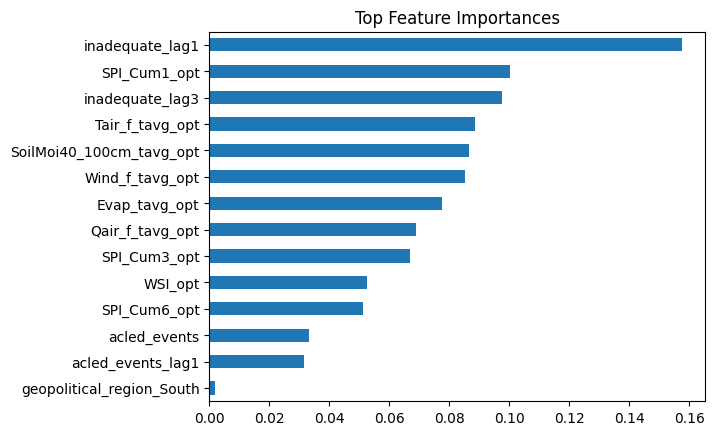

In [21]:
feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top Feature Importances")
plt.show()

In [22]:
# Examiner les erreurs de prévision par état
# On utilise best_model et on passe X_test directement sans DMatrix
test_pred = best_model.predict(X_test)

test_results = pd.DataFrame({'true': y_test, 'pred': test_pred}, index=X_test.index)
# On récupère le nom des États depuis le dataframe principal
test_results = test_results.join(df_ml.loc[X_test.index, ['NAME_1']], how='left')
test_results['error'] = test_results['true'] - test_results['pred']

# On agrège les erreurs par État
error_by_state = test_results.groupby('NAME_1')['error'].agg(['mean', 'std']).sort_values(by='mean')

print(f"\n=== Forecast Error by State ===")
print(error_by_state.head(10).to_string())



=== Forecast Error by State ===
               mean       std
NAME_1                       
Bauchi    -0.070711  0.132521
Zamfara   -0.063290  0.143180
Nassarawa -0.051560  0.045781
Niger     -0.050987  0.162344
Taraba    -0.048366  0.157713
Katsina   -0.047286  0.156239
Sokoto    -0.044611  0.158816
Kebbi     -0.044361  0.153725
Jigawa    -0.043871  0.140856
Kano      -0.041850  0.154629


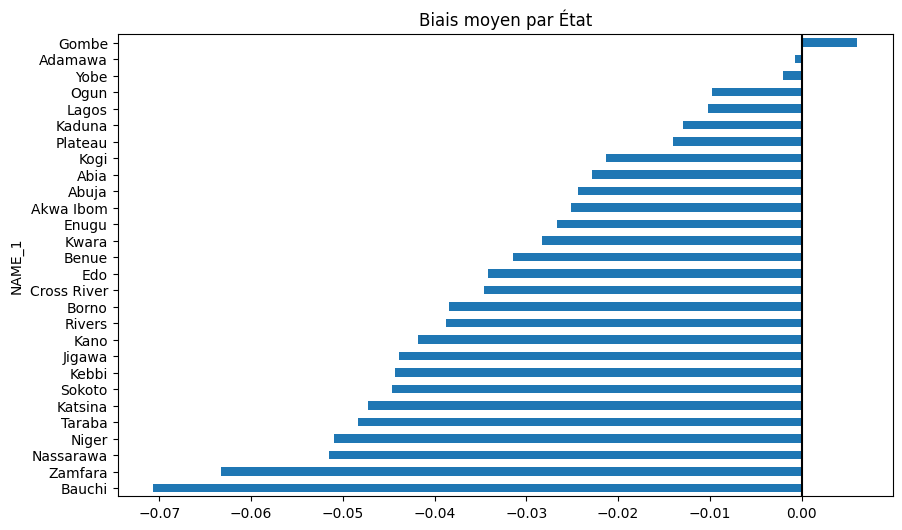

In [23]:
error_by_state['mean'].plot(kind='barh', figsize=(10,6))
plt.axvline(0, color='black')
plt.title("Biais moyen par État")
plt.show()

Les résultats mettent en évidence un biais systématique du modèle, qui tend à surestimer la variation de l’insécurité alimentaire dans l’ensemble des États analysés, comme l’indiquent les erreurs moyennes négatives. Autrement dit, le modèle prédit des détériorations plus importantes que celles réellement observées. Ce biais est particulièrement marqué dans des régions vulnérables comme Bauchi, Zamfara ou Niger, ce qui suggère que le modèle capte bien les zones à risque mais exagère l’intensité des chocs, probablement en raison de l’absence de variables reflétant les mécanismes d’adaptation locaux (résilience des populations, aides humanitaires, ajustements des marchés). Par ailleurs, la variabilité des erreurs diffère selon les États, certaines zones présentant des erreurs plus instables, ce qui traduit une hétérogénéité spatiale dans la performance du modèle. Globalement, ces résultats indiquent que si le modèle est pertinent pour identifier les dynamiques de risque, il reste limité dans sa capacité à en quantifier précisément l’ampleur.
